<a href="https://colab.research.google.com/github/PrishitaM/Bike-Sharing-Demand-Prediction/blob/main/Bike_Sharing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Problem Statement**

### Business Context

Bike-sharing systems are a new generation of traditional bike rentals where the whole process from membership, rental and return has become automatic. Through these systems, the user can easily rent a bike from a particular position and return to another position. Currently, there are about over 500 bike-sharing programs around the world which are composed of over 500 thousand bicycles. Today, there exists a great interest in these systems due to their important role in traffic, environmental, and health issues.

### Objective

'Travel Along' is a new bike-sharing company and wants to expand its customer count and provide better services at a reasonable cost. They have conducted several surveys and collated the data about weather, weekends, holidays, etc. from the past 2 years.

As a recently hired data scientist at 'Travel Along', you have been asked to analyze the patterns in the data and figure out the key areas which can help the organization to grow and manage the customer demands. Further, you need to use this information to predict the count of bikes shared so that the company can take prior decisions for surge hours.
- What are the different factors which affect the target variable? What business recommendations can we give based on the analysis?
- How can we use different ensemble techniques - Bagging, Boosting, and Stacking to build a model to predict the count of bikes rented?

### Dataset

The bike-sharing rental process is highly correlated to the environmental and seasonal settings.

- instant: record index
- dteday: date
- season: season (1:spring, 2:summer, 3:fall, 4:winter)
- yr: year (0: 2011, 1:2012)
- mnth: month (1 to 12)
- hr: hour (0 to 23)
- holiday: whether the day is holiday or not
- weekday: day of the week
- workingday: if day is neither weekend nor holiday then 1, otherwise 0
- weathersit:
	- 1: Clear, Few clouds, Partly cloudy
	- 2: Mist + Cloudy, Mist + Broken clouds
	- 3: Light Snow, Light Rain + Thunderstorm
	- 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist
- temp: Normalized temperature in Celsius
- atemp: Normalized feeling temperature in Celsius
- hum: Normalized humidity
- windspeed: Normalized wind speed
- casual: count of casual users
- registered: count of registered users
- cnt: count of total rental bikes including both casual and registered

## Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

## Load Dataset

In [2]:
data = pd.read_csv('hour.csv')

In [3]:
data.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [4]:
data.tail()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61
17378,17379,2012-12-31,1,1,12,23,0,1,1,1,0.26,0.2727,0.65,0.1343,12,37,49


In [5]:
data.shape

(17379, 17)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [7]:
data.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [8]:
data.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


**Observations -**
* 17,379 rows and 17 columns.
* No null values in the dataset.
* instant is just an ID column and dteday is a date column - both can be dropped.

In [9]:
data.nunique()

,0
instant,17379
dteday,731
season,4
yr,2
mnth,12
hr,24
holiday,2
weekday,7
workingday,2
weathersit,4


In [10]:
data.drop(columns=['instant', 'dteday'], inplace=True)

**Category value counts**

In [11]:
for col in ['season', 'yr', 'holiday', 'workingday', 'weathersit']:
    print(data[col].value_counts())
    print('-'*30)

season
3    4496
2    4409
1    4242
4    4232
Name: count, dtype: int64
------------------------------
yr
1    8734
0    8645
Name: count, dtype: int64
------------------------------
holiday
0    16879
1      500
Name: count, dtype: int64
------------------------------
workingday
1    11865
0     5514
Name: count, dtype: int64
------------------------------
weathersit
1    11413
2     4544
3     1419
4        3
Name: count, dtype: int64
------------------------------


* Most days are non-holidays and working days.
* Most common weather is clear/partly cloudy (weathersit=1).
* weathersit=4 has only 3 observations.

In [12]:
df = data.copy()

## **Exploratory Data Analysis**

**Target Variable**

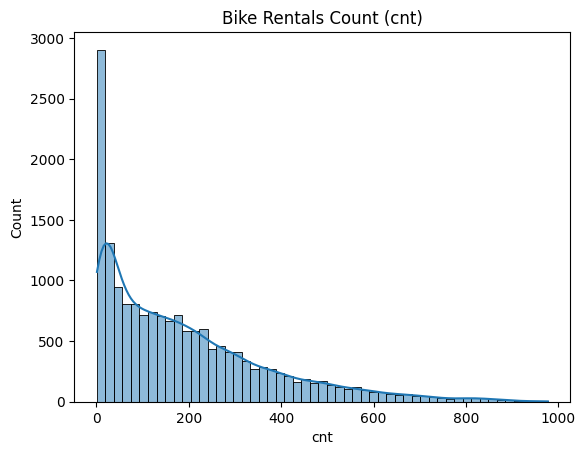

In [13]:
sns.histplot(data['cnt'], kde=True)
plt.title('Bike Rentals Count (cnt)')
plt.show()

* The target variable is right-skewed with many low-count hours and some very high-demand hours.

### Univariate Analysis

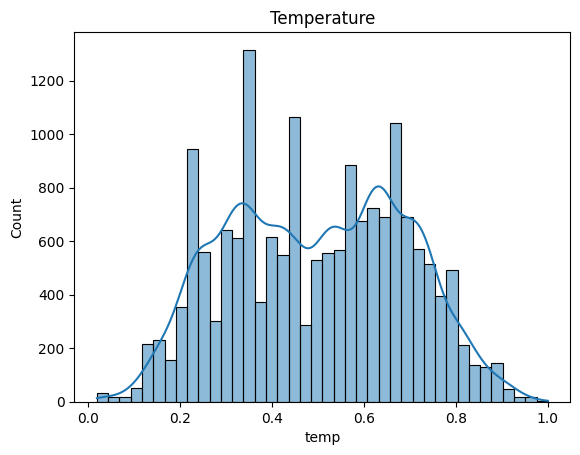

In [14]:
sns.histplot(data['temp'], kde=True)
plt.title('Temperature')
plt.show()

* Temperature is approximately symmetrically distributed with mean and median around 0.5.

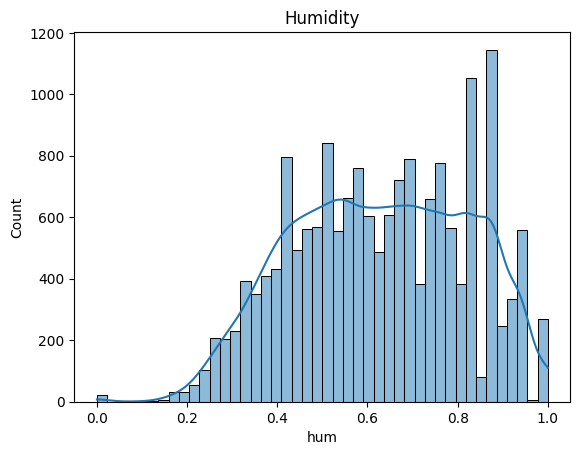

In [15]:
sns.histplot(data['hum'], kde=True)
plt.title('Humidity')
plt.show()

* Humidity is approximately normally distributed. A value of 0 is an outlier.

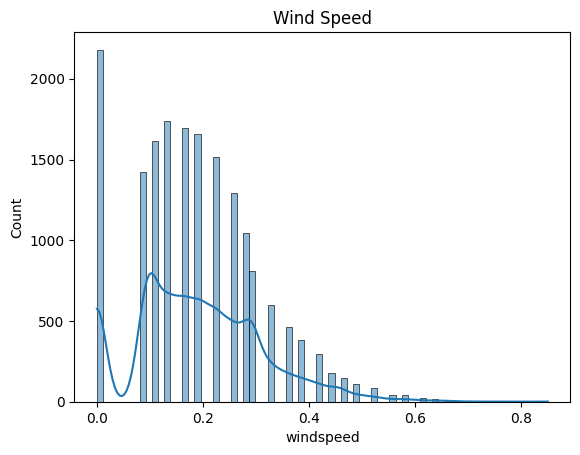

In [16]:
sns.histplot(data['windspeed'], kde=True)
plt.title('Wind Speed')
plt.show()

* Wind speed is right-skewed. 0 has the highest count. Many outliers exist.

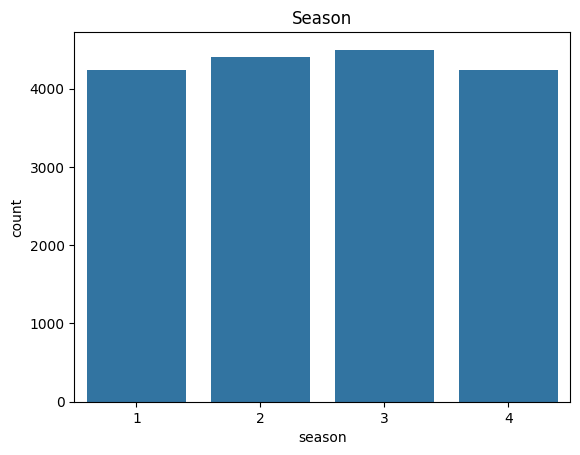

In [17]:
sns.countplot(x='season', data=data)
plt.title('Season')
plt.show()

* Each season has approximately 24% of observations.

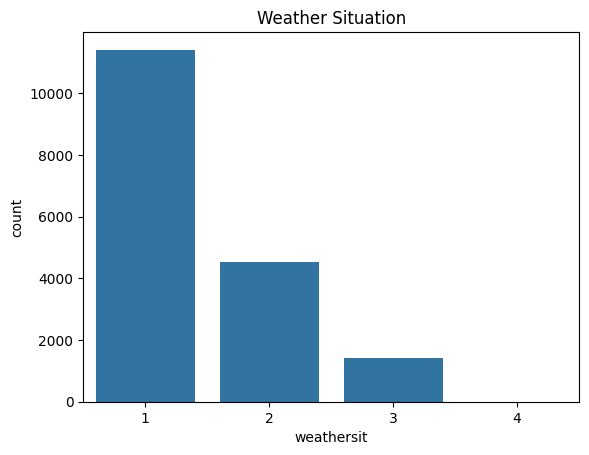

In [18]:
sns.countplot(x='weathersit', data=data)
plt.title('Weather Situation')
plt.show()

* Clear weather (weathersit=1) accounts for 65.7% of observations.

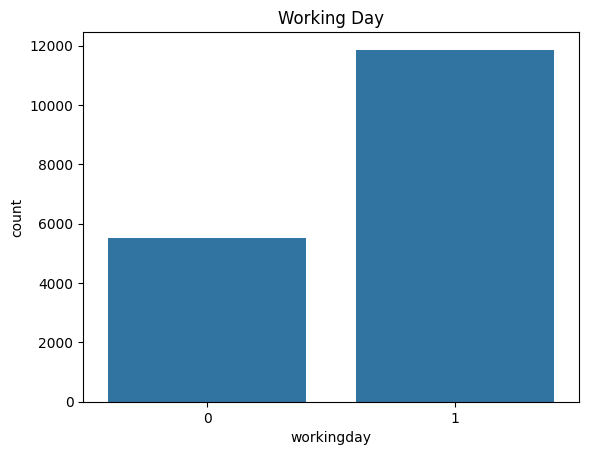

In [19]:
sns.countplot(x='workingday', data=data)
plt.title('Working Day')
plt.show()

* ~68% of observations are working days.

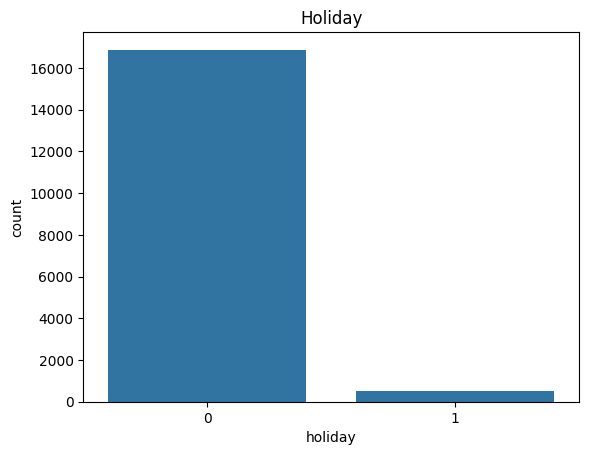

In [20]:
sns.countplot(x='holiday', data=data)
plt.title('Holiday')
plt.show()

* 97% of observations are non-holidays.

### Bivariate Analysis

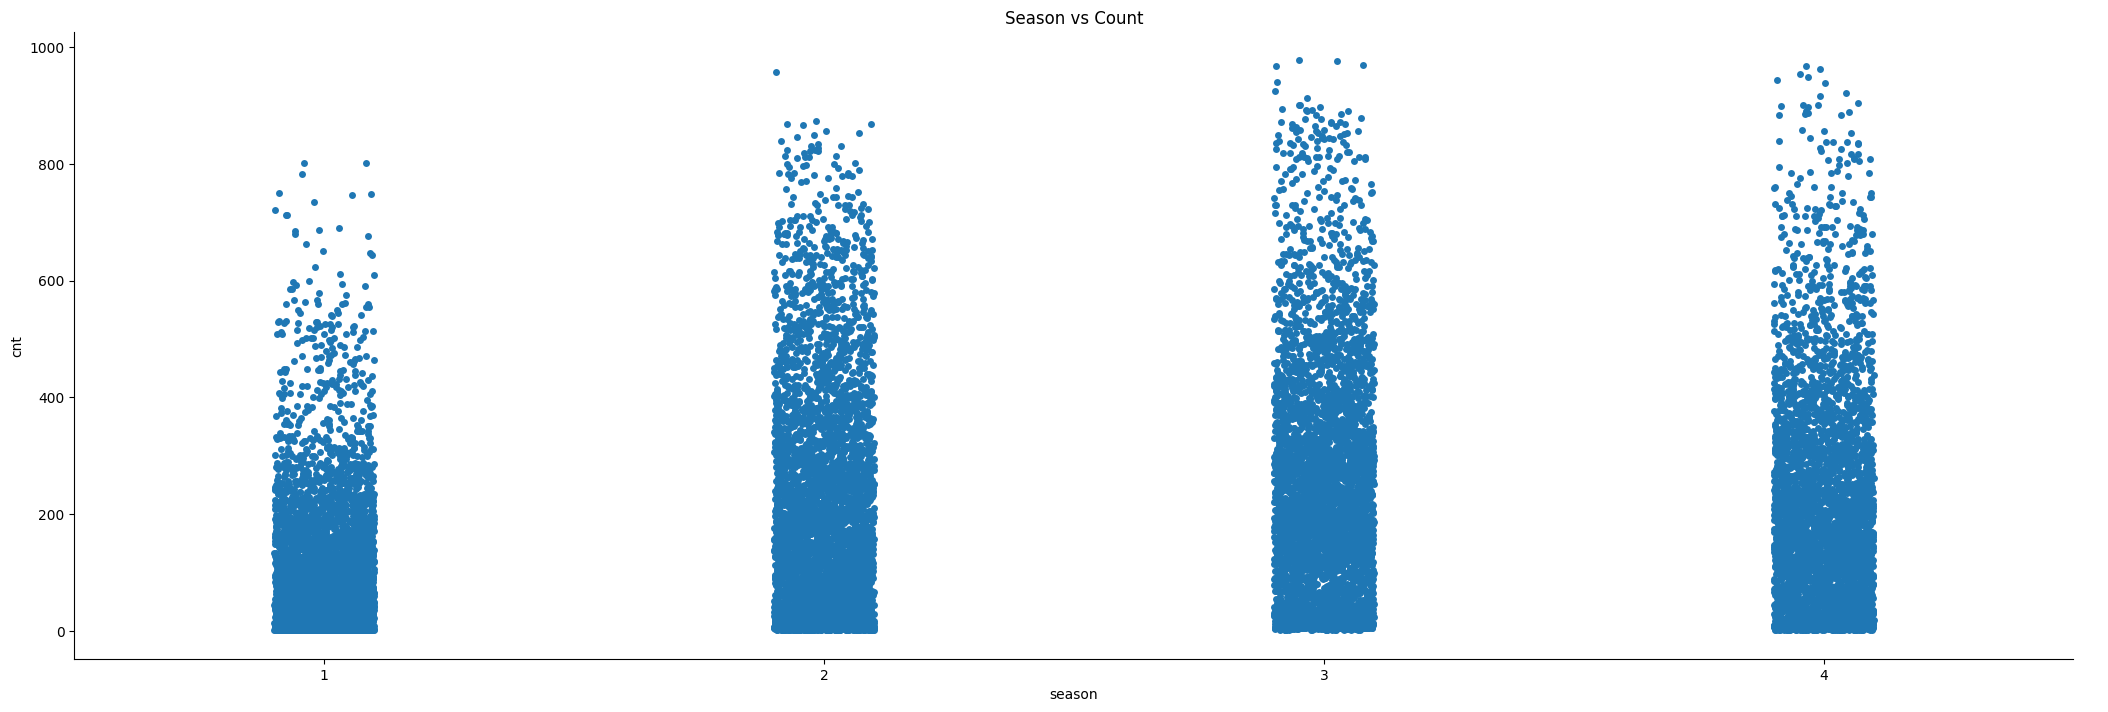

In [21]:
sns.catplot(x='season', y='cnt', kind='strip', data=data, jitter=True, height=7, aspect=3)
plt.title('Season vs Count')
plt.show()

* Fewest rentals in spring (season 1). Most rentals in fall (season 3).

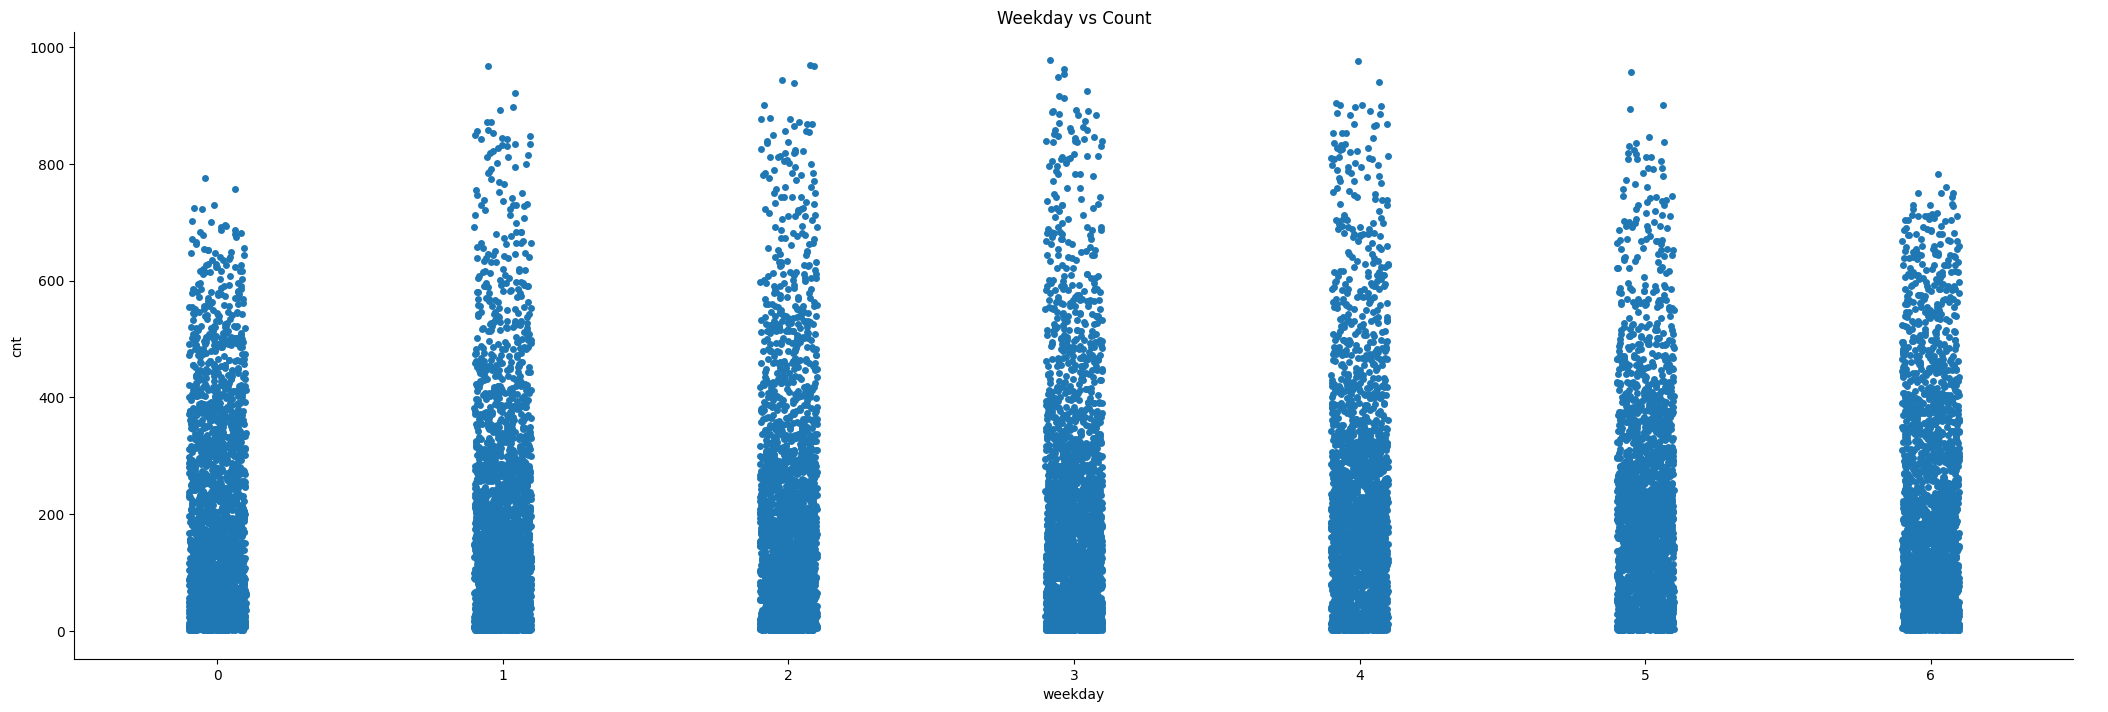

In [22]:
sns.catplot(x='weekday', y='cnt', kind='strip', data=data, jitter=True, height=7, aspect=3)
plt.title('Weekday vs Count')
plt.show()

* Weekends (0 and 6) have lower and less variable rental counts. Working days have more rentals and more variation.

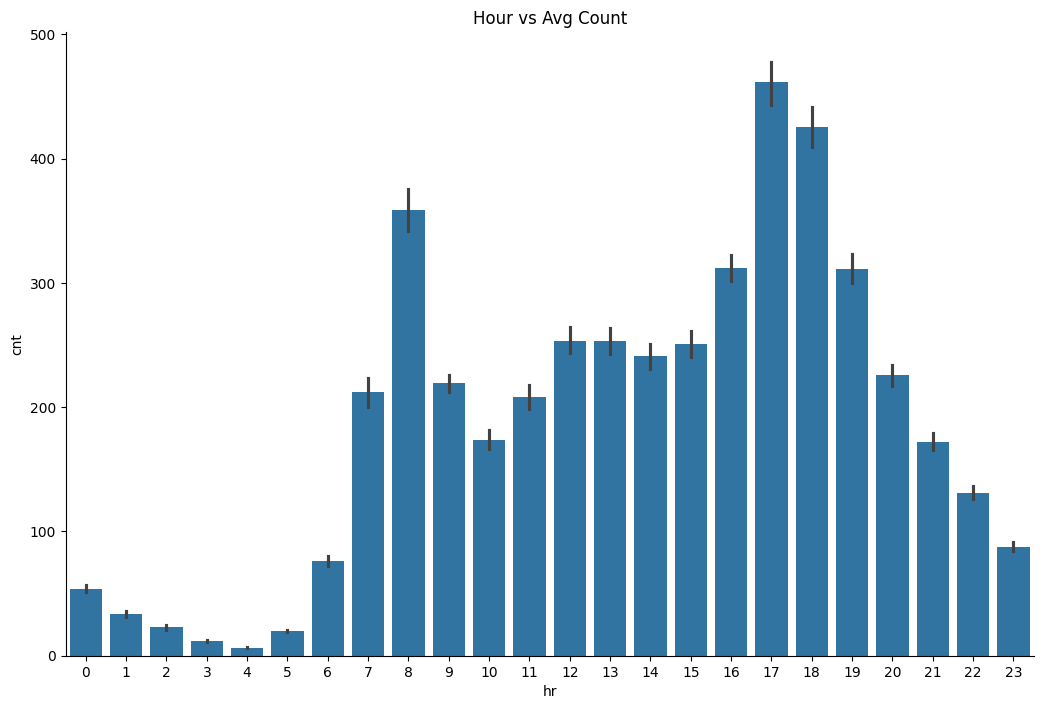

In [23]:
sns.catplot(x='hr', y='cnt', data=data, kind='bar', height=7, aspect=1.5, estimator=np.mean)
plt.title('Hour vs Avg Count')
plt.show()

* Peak rentals at 8 AM and 5-6 PM (commute hours). Very low counts from midnight to 5 AM.

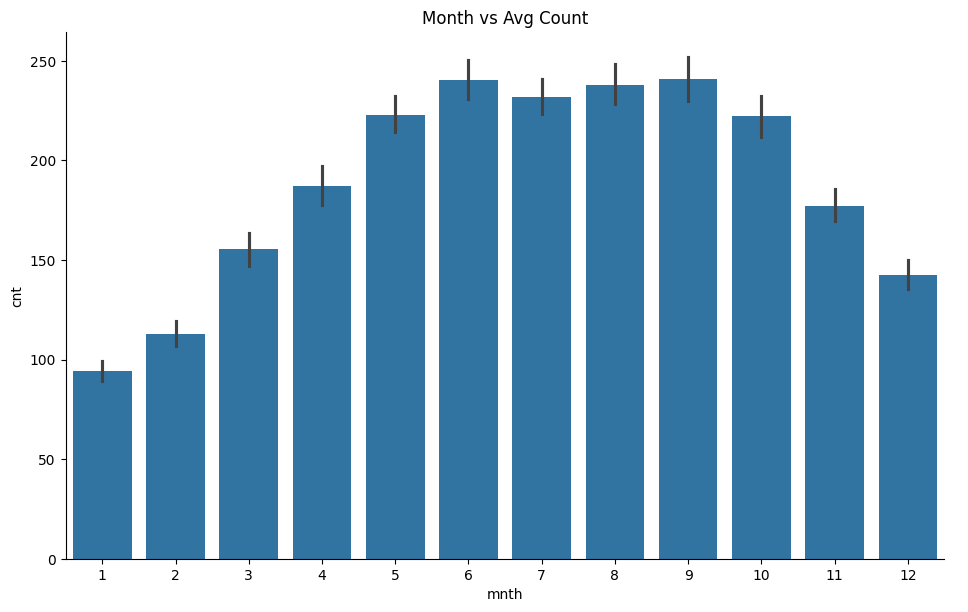

In [24]:
sns.catplot(x='mnth', y='cnt', data=data, kind='bar', height=6, aspect=1.6, estimator=np.mean)
plt.title('Month vs Avg Count')
plt.show()

* Low rentals in December, January, February. Consistently high rentals from May to October.

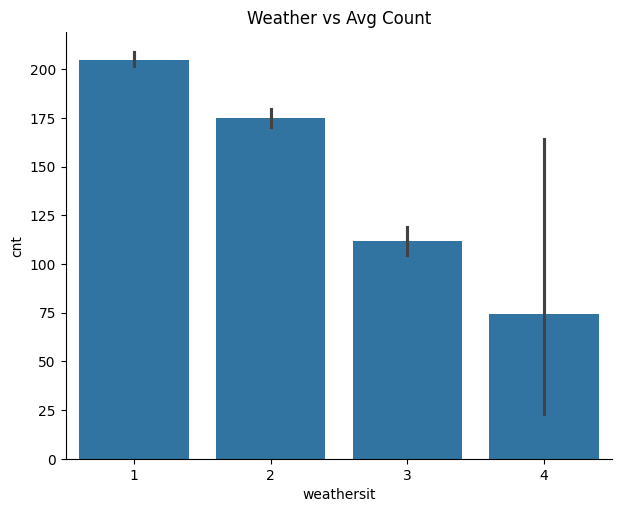

In [25]:
sns.catplot(x='weathersit', y='cnt', kind='bar', data=data, aspect=1.25, estimator=np.mean)
plt.title('Weather vs Avg Count')
plt.show()

* Clear weather has much higher average rentals than rainy or snowy weather.

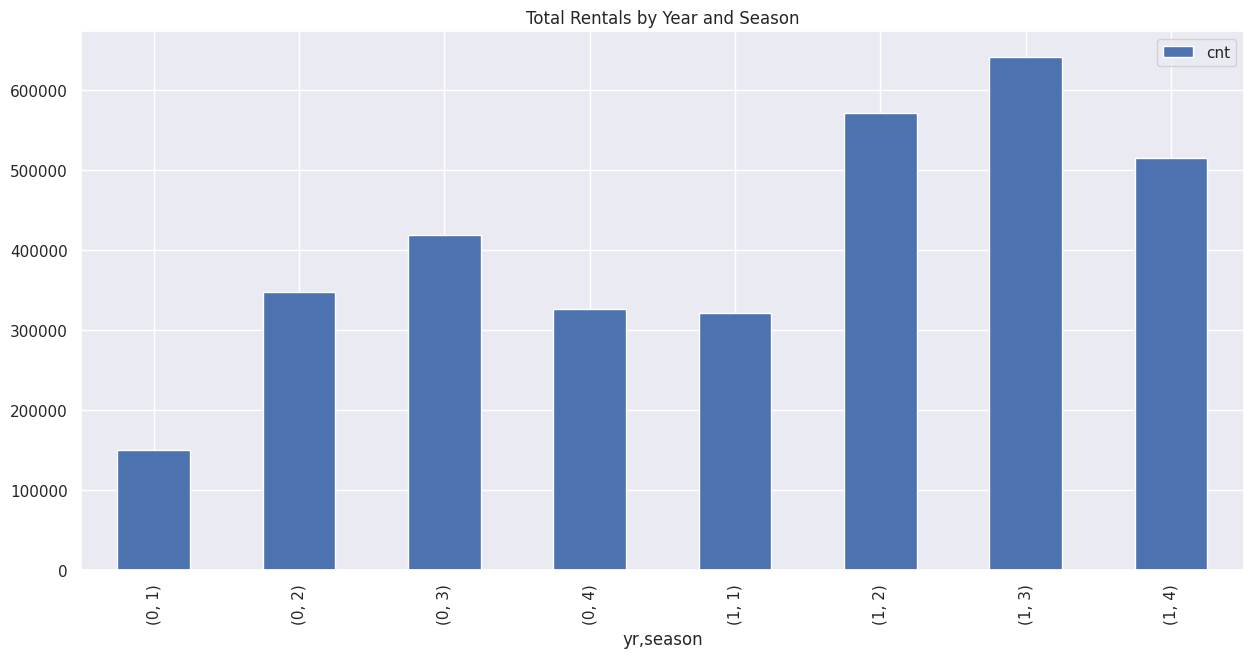

In [26]:
sns.set(rc={'figure.figsize': (15, 7)})
pd.pivot_table(data=data, index=['yr', 'season'], values='cnt', aggfunc=np.sum).plot(kind='bar')
plt.title('Total Rentals by Year and Season')
plt.show()

* Rentals are higher in 2012 across every season, showing that bike-sharing is growing in popularity.

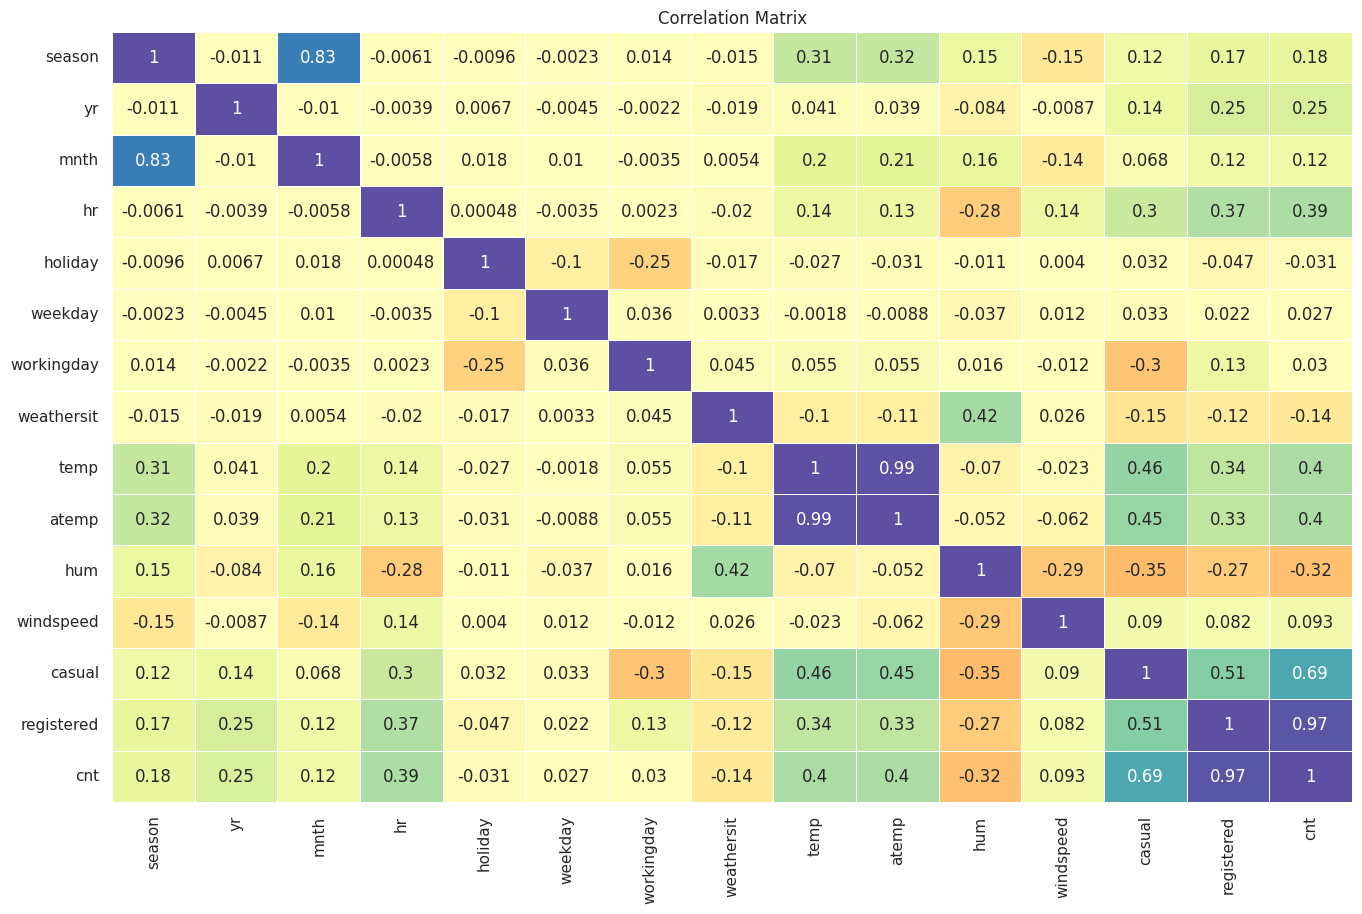

In [27]:
sns.set(rc={'figure.figsize': (16, 10)})
sns.heatmap(data.corr(numeric_only=True), annot=True, linewidths=0.5, center=0, cbar=False, cmap='Spectral')
plt.title('Correlation Matrix')
plt.show()

* temp and atemp are almost perfectly correlated.
* casual and registered together make up cnt - we will drop them before modelling.
* hr is most correlated with cnt among all features.

## **Data Preprocessing**

**Outlier Detection**

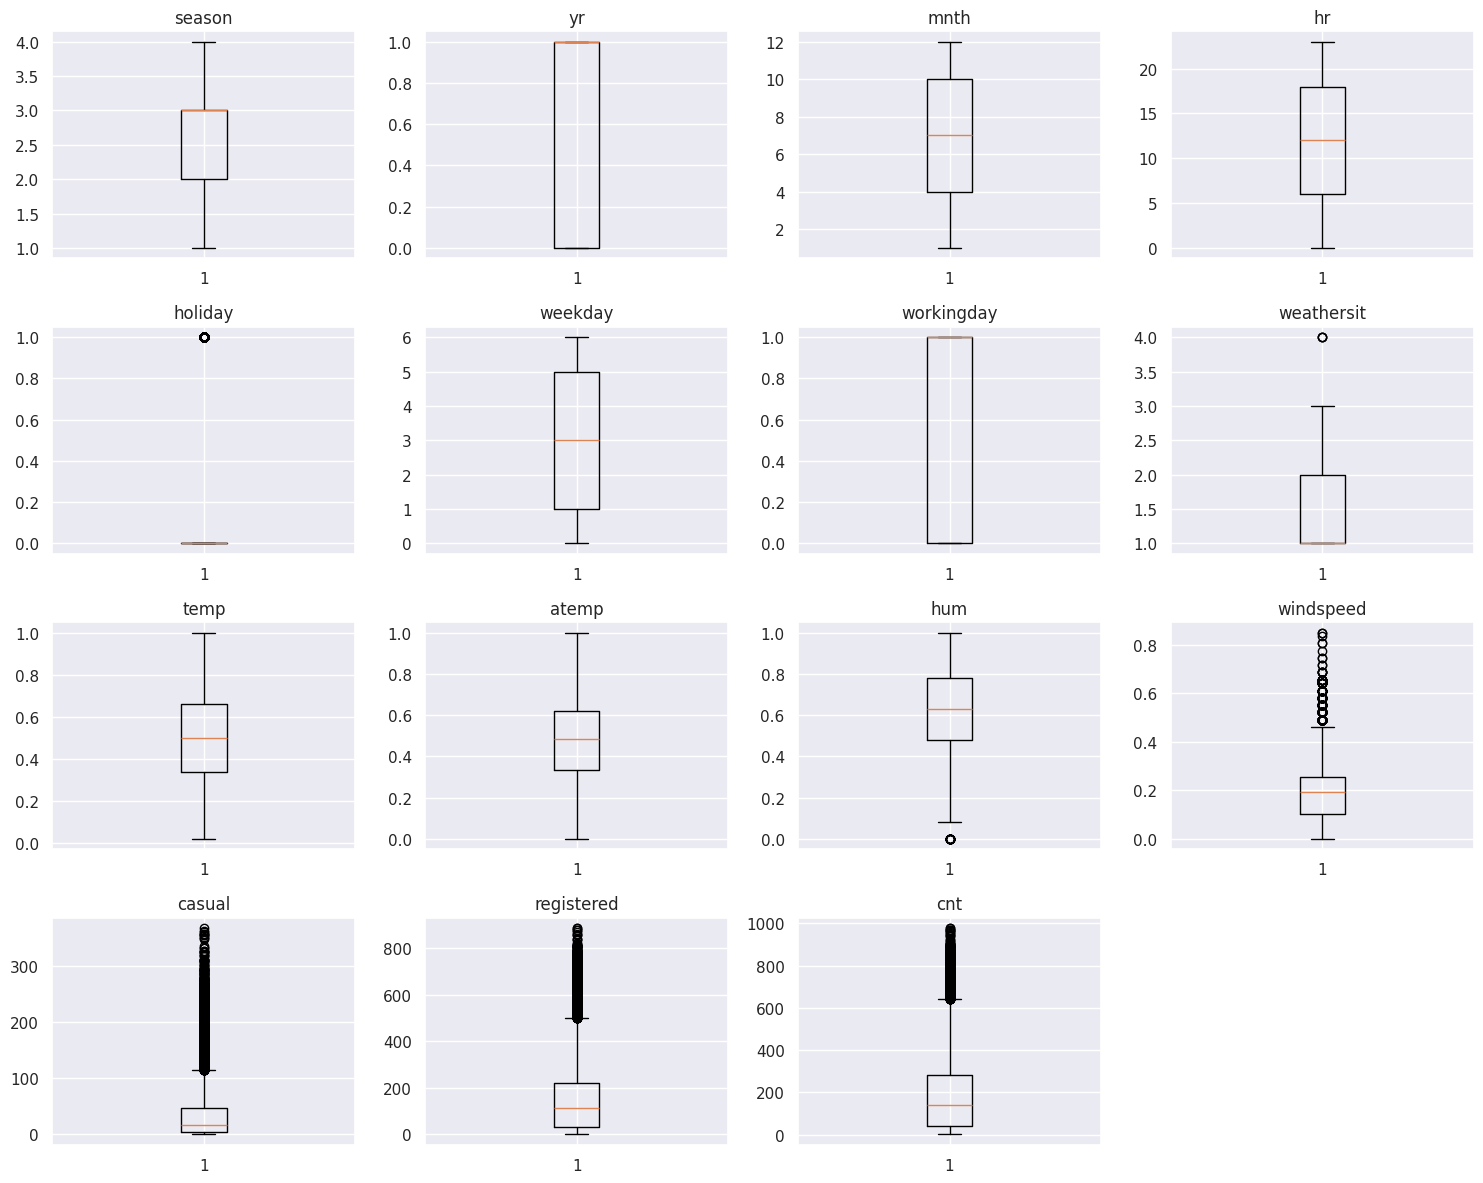

In [28]:
num_cols = data.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(15, 12))
for i, variable in enumerate(num_cols):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)
plt.show()

* Outliers exist in several columns but will not be treated as they are valid observations.

**Dropping casual and registered** - cnt is just their sum, so they can't be used as features.

In [29]:
data.drop(columns=['casual', 'registered'], inplace=True)
data.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


**Encoding and Train-Test Split**

In [30]:
data[['season', 'weathersit']] = data[['season', 'weathersit']].astype(str)

In [31]:
X = data.drop('cnt', axis=1)
y = data['cnt']

X = pd.get_dummies(X, columns=['season', 'weathersit'], drop_first=True)
X = X.astype(float)
print(X.shape)

(17379, 16)


In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1, shuffle=True)
print(X_train.shape, X_test.shape)

(12165, 16) (5214, 16)


## **Model Building**

**We use R² and RMSE to evaluate models. Higher R² and lower RMSE = better.**

In [33]:
def get_scores(model):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    print('Train R2 :', r2_score(y_train, train_pred))
    print('Test  R2 :', r2_score(y_test, test_pred))
    print('Train RMSE:', np.sqrt(mean_squared_error(y_train, train_pred)))
    print('Test  RMSE:', np.sqrt(mean_squared_error(y_test, test_pred)))

### Random Forest

In [34]:
rf = RandomForestRegressor(random_state=1)
rf.fit(X_train, y_train)
get_scores(rf)

Train R2 : 0.9918334655124836
Test  R2 : 0.9403794194159618
Train RMSE: 16.235969208683105
Test  RMSE: 45.24246069141948


* Random Forest gives a high R² on training data but is slightly overfitting.

**Hyperparameter Tuning - Random Forest**

In [35]:
params_rf = {
    'n_estimators': [50, 75, 100, 125, 150],
    'max_depth': [3, 4, 5],
    'min_samples_split': [20, 30, 40],
    'max_features': ['sqrt', 0.6, 0.8]
}

rand_rf = RandomizedSearchCV(RandomForestRegressor(random_state=1), params_rf,
                             scoring='r2', cv=5, random_state=1)
rand_rf.fit(X_train, y_train)
best_rf = rand_rf.best_estimator_

get_scores(best_rf)

Train R2 : 0.657566166228009
Test  R2 : 0.6659575029318359
Train RMSE: 105.13508080486508
Test  RMSE: 107.09001466760851


* Tuning did not lead to significant improvement. Results remain largely the same.

### AdaBoost

In [36]:
ada = AdaBoostRegressor(random_state=1)
ada.fit(X_train, y_train)
get_scores(ada)

Train R2 : 0.6668277667292444
Test  R2 : 0.6754245176557435
Train RMSE: 103.70357274742618
Test  RMSE: 105.56160210665931


* AdaBoost generalizes well but gives poorer performance compared to Random Forest in terms of R² and RMSE.

**Hyperparameter Tuning - AdaBoost**

In [44]:
params_ada = {
    'n_estimators': [50, 75, 100, 125, 150],
    'learning_rate': [0.1, 0.05, 0.01]
}

rand_ada = RandomizedSearchCV(AdaBoostRegressor(random_state=1), params_ada,
                              scoring='r2', cv=5, random_state=1)
rand_ada.fit(X_train, y_train)
best_ada = rand_ada.best_estimator_

get_scores(best_ada)

Train R2 : 0.638826658510856
Test  R2 : 0.6550961112564144
Train RMSE: 107.973495765208
Test  RMSE: 108.8171037885039


* No significant improvement after tuning AdaBoost.

### Gradient Boosting

In [39]:
gb = GradientBoostingRegressor(random_state=1)
gb.fit(X_train, y_train)
get_scores(gb)

Train R2 : 0.8419361230312103
Test  R2 : 0.8421318427554928
Train RMSE: 71.42917495385927
Test  RMSE: 73.6199277825879


* Gradient Boosting generalizes well but not as strong as Random Forest by default.

**Hyperparameter Tuning - Gradient Boosting**

In [40]:
params_gb = {
    'n_estimators': [75, 100, 125],
    'subsample': [0.7, 0.8],
    'max_features': ['sqrt', 0.6, 0.8],
    'max_depth': [3, 4]
}

rand_gb = RandomizedSearchCV(GradientBoostingRegressor(random_state=1), params_gb,
                             scoring='r2', cv=5, random_state=1)
rand_gb.fit(X_train, y_train)
best_gb = rand_gb.best_estimator_

get_scores(best_gb)

Train R2 : 0.9230457406357969
Test  R2 : 0.92009428924302
Train RMSE: 49.83972646855837
Test  RMSE: 52.37656668224478


* Tuned Gradient Boosting shows significant improvement. R² increases and RMSE drops on the test set.

### XGBoost

In [41]:
xgb = XGBRegressor(random_state=1, verbosity=0)
xgb.fit(X_train, y_train)
get_scores(xgb)

Train R2 : 0.9765582084655762
Test  R2 : 0.9510456919670105
Train RMSE: 27.50773262200842
Test  RMSE: 40.996203735262185


* XGBoost with default parameters already gives results close to the tuned Gradient Boosting model.

**Hyperparameter Tuning - XGBoost**

In [42]:
params_xgb = {
    'n_estimators': [75, 100, 125, 150],
    'subsample': [0.7, 0.8, 0.9],
    'gamma': [0, 1, 5],
    'colsample_bytree': [0.7, 0.8],
    'colsample_bylevel': [0.6, 0.7]
}

rand_xgb = RandomizedSearchCV(XGBRegressor(random_state=1, verbosity=0), params_xgb,
                              scoring='r2', cv=5, random_state=1)
rand_xgb.fit(X_train, y_train)
best_xgb = rand_xgb.best_estimator_

get_scores(best_xgb)

Train R2 : 0.9730640649795532
Test  R2 : 0.9469555020332336
Train RMSE: 29.48665925008238
Test  RMSE: 42.674479563958215


## **Model Performance Comparison**

In [45]:
results = {}

for name, model in [
    ('RF', rf), ('RF_Tuned', best_rf),
    ('AdaBoost', ada), ('AdaBoost_Tuned', best_ada),
    ('GradBoost', gb), ('GradBoost_Tuned', best_gb),
    ('XGBoost', xgb), ('XGBoost_Tuned', best_xgb)
]:
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    results[name] = [
        r2_score(y_train, train_pred),
        r2_score(y_test, test_pred),
        np.sqrt(mean_squared_error(y_train, train_pred)),
        np.sqrt(mean_squared_error(y_test, test_pred))
    ]

comparison_df = pd.DataFrame(results, index=['Train R2', 'Test R2', 'Train RMSE', 'Test RMSE'])
print('Model Performance Comparison:')
comparison_df

Model Performance Comparison:


,RF,RF_Tuned,AdaBoost,AdaBoost_Tuned,GradBoost,GradBoost_Tuned,XGBoost,XGBoost_Tuned
Train R2,0.991833,0.657566,0.666828,0.638827,0.841936,0.923046,0.976558,0.973064
Test R2,0.940379,0.665958,0.675425,0.655096,0.842132,0.920094,0.951046,0.946956
Train RMSE,16.235969,105.135081,103.703573,107.973496,71.429175,49.839726,27.507733,29.486659
Test RMSE,45.242461,107.090015,105.561602,108.817104,73.619928,52.376567,40.996204,42.674480


In [46]:
best_model_name = comparison_df.loc['Test R2'].idxmax()
print('Best Model (by Test R2):', best_model_name)

Best Model (by Test R2): XGBoost


* The untuned XGBoost gives the best overall performance with lowest RMSE and highest R² on the test set.
* Tuning XGBoost slightly degrades performance, so the base XGBoost model is selected as the final model.

## **Final Model - Feature Importance**

In [47]:
final_model = xgb

In [48]:
print(pd.DataFrame(final_model.feature_importances_, columns=['Imp'],
             index=X_train.columns).sort_values(by='Imp', ascending=False))

                   Imp
workingday    0.276971
hr            0.211171
yr            0.149279
temp          0.089540
weathersit_3  0.068012
season_4      0.065931
atemp         0.057047
mnth          0.018761
weekday       0.013390
holiday       0.013100
hum           0.013046
season_2      0.009687
season_3      0.004952
weathersit_2  0.004781
windspeed     0.004191
weathersit_4  0.000140


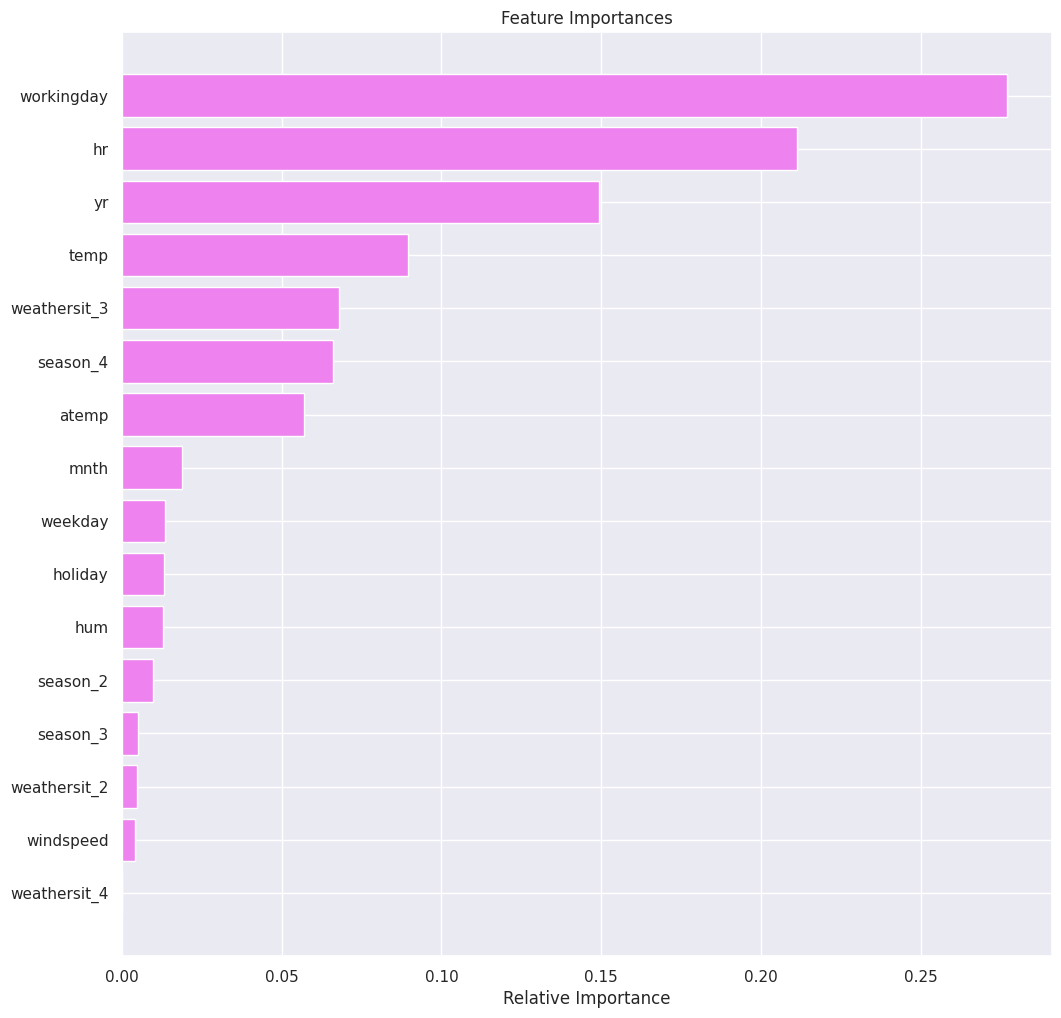

In [49]:
importances = final_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [X_train.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

* hr (hour of day) is the most important feature, followed by yr (year) and workingday.

**Observed vs Predicted Plot**

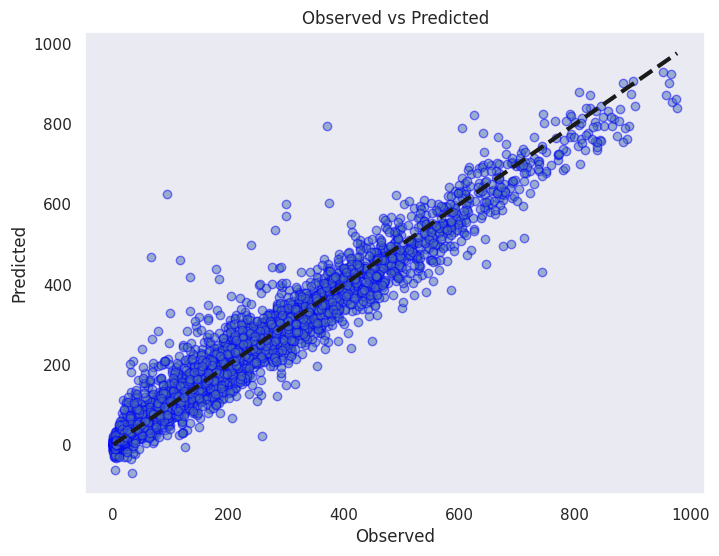

In [50]:
y_pred = final_model.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, edgecolors=(0, 0, 1), alpha=0.5)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=3)
ax.set_xlabel('Observed')
ax.set_ylabel('Predicted')
ax.set_title('Observed vs Predicted')
plt.grid()
plt.show()

* Most predicted values are close to actual values. Points are dense along the diagonal line.

## **Conclusions and Business Recommendations**

### Conclusions

1. The model can accurately forecast hourly bike rentals using seasonal and environmental features.
2. Bike rentals peak at 8 AM and 5-6 PM, matching office and school commute hours.
3. Fall (season 3) has the highest rentals; spring (season 1) has the lowest.
4. Rentals are higher on working days and in good weather.
5. Bike-sharing is growing year over year - 2012 had more rentals than 2011 across every season.
6. hr, workingday, and yr are the most important predictors of bike demand.

### Business Recommendations

1. Ensure more bikes are available during morning and evening peak hours (8 AM and 5-6 PM).
2. Make more bikes available during fall and summer seasons to meet higher demand.
3. Place more stations near offices, schools, and colleges - the main commuter segments.
4. Adjust bike availability based on weather forecasts to avoid shortages or excess.
5. Schedule all maintenance activities during nighttime (midnight to 5 AM) when usage is minimal.
6. Introduce weekend and holiday promotions to boost rentals during low-demand periods.

## **Appendix: Detailed EDA**

### Univariate Analysis

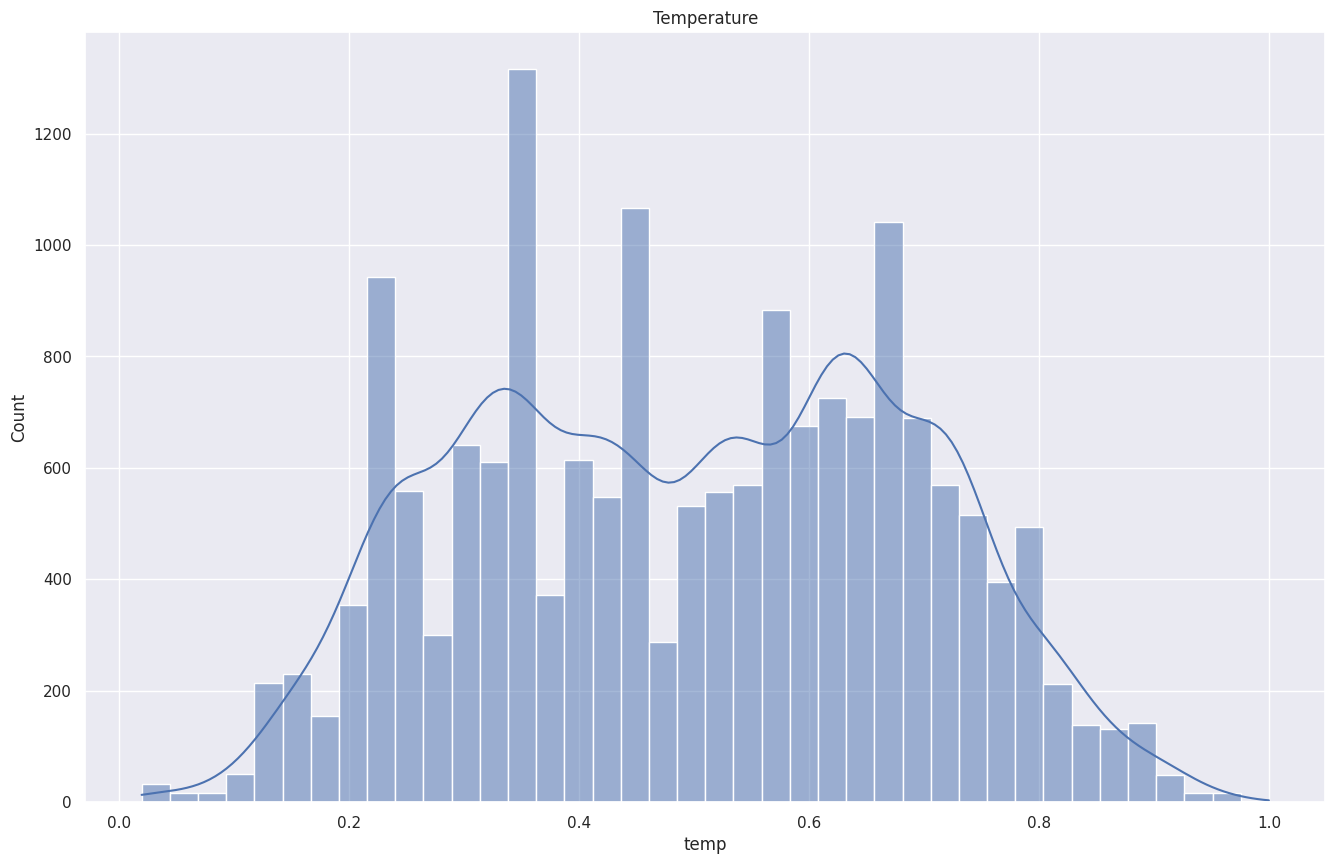

In [51]:
sns.histplot(df['temp'], kde=True)
plt.title('Temperature')
plt.show()

* Approximately symmetric distribution with mean and median around 0.5. No outliers.

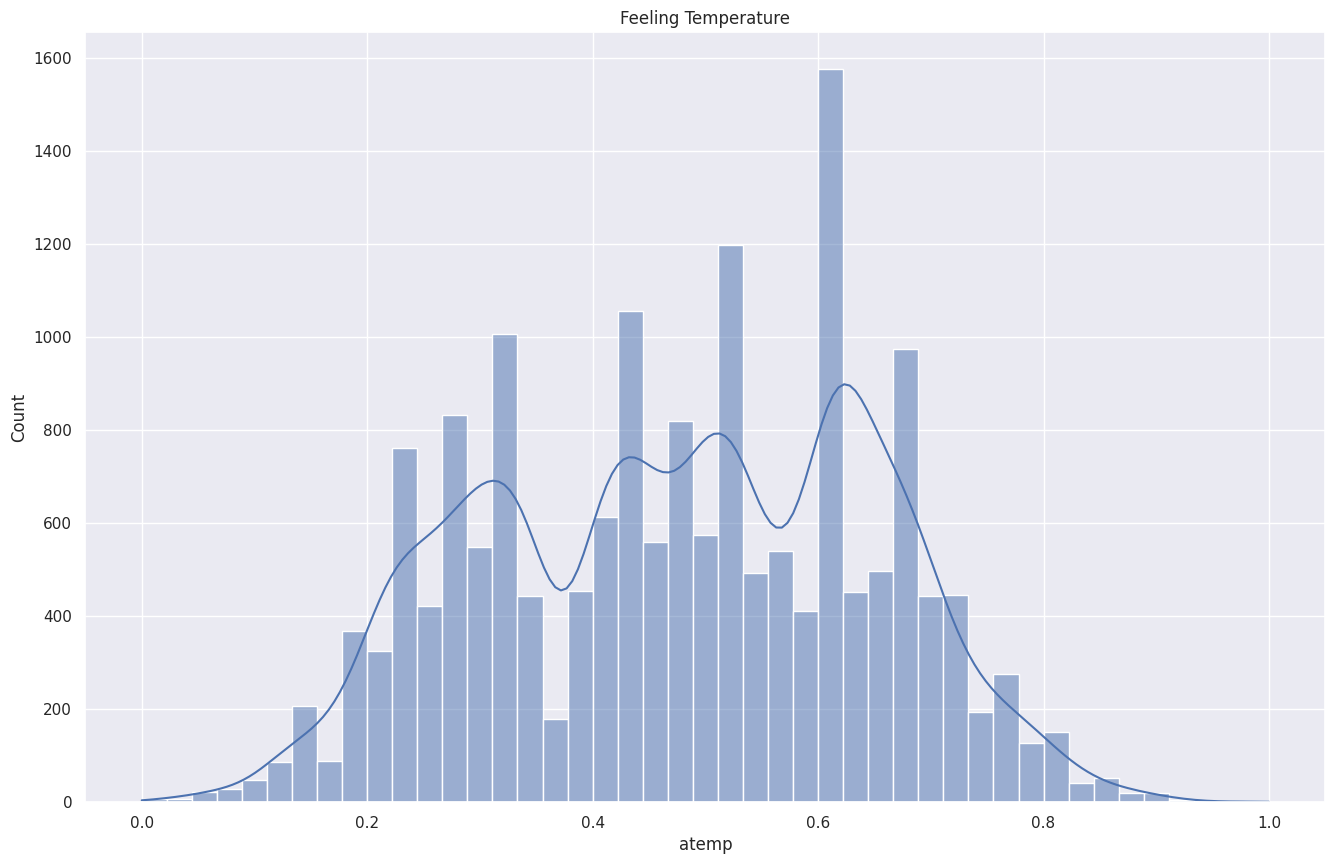

In [52]:
sns.histplot(df['atemp'], kde=True)
plt.title('Feeling Temperature')
plt.show()

* Same as temp - symmetrically distributed. No outliers.

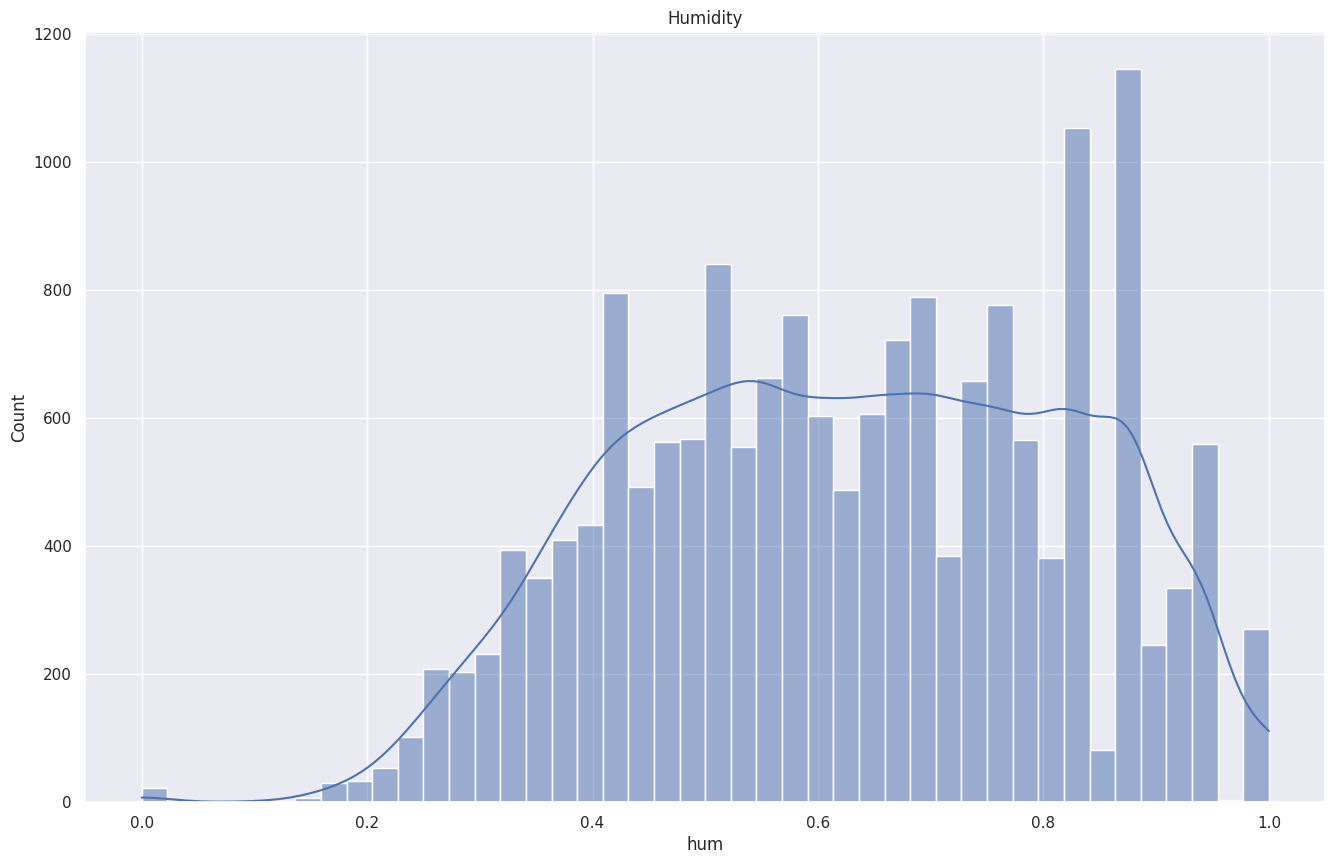

In [53]:
sns.histplot(df['hum'], kde=True)
plt.title('Humidity')
plt.show()

* Approximately normal with mean around 0.63. A value of 0 is an outlier.

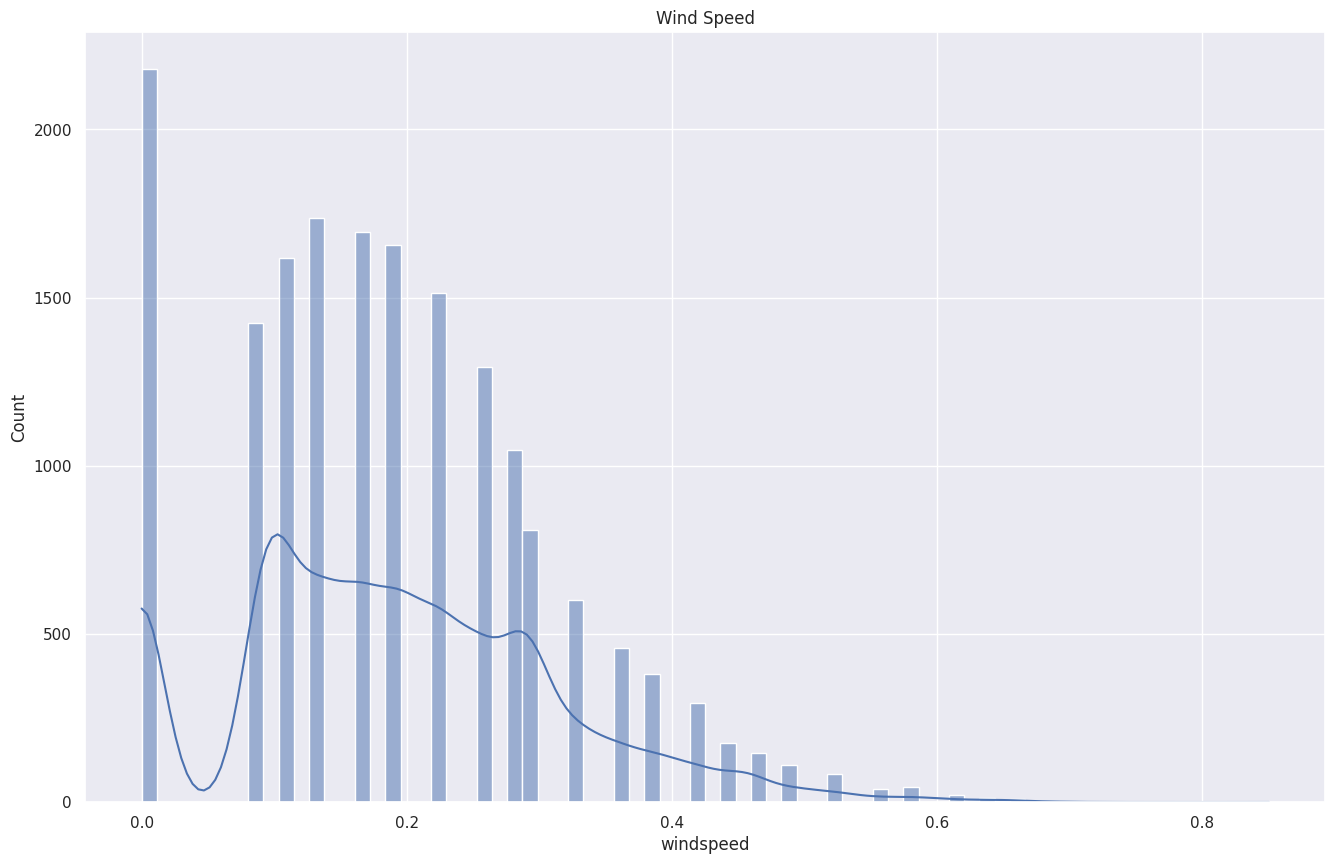

In [54]:
sns.histplot(df['windspeed'], kde=True)
plt.title('Wind Speed')
plt.show()

* Right-skewed. Many outliers on the right side.

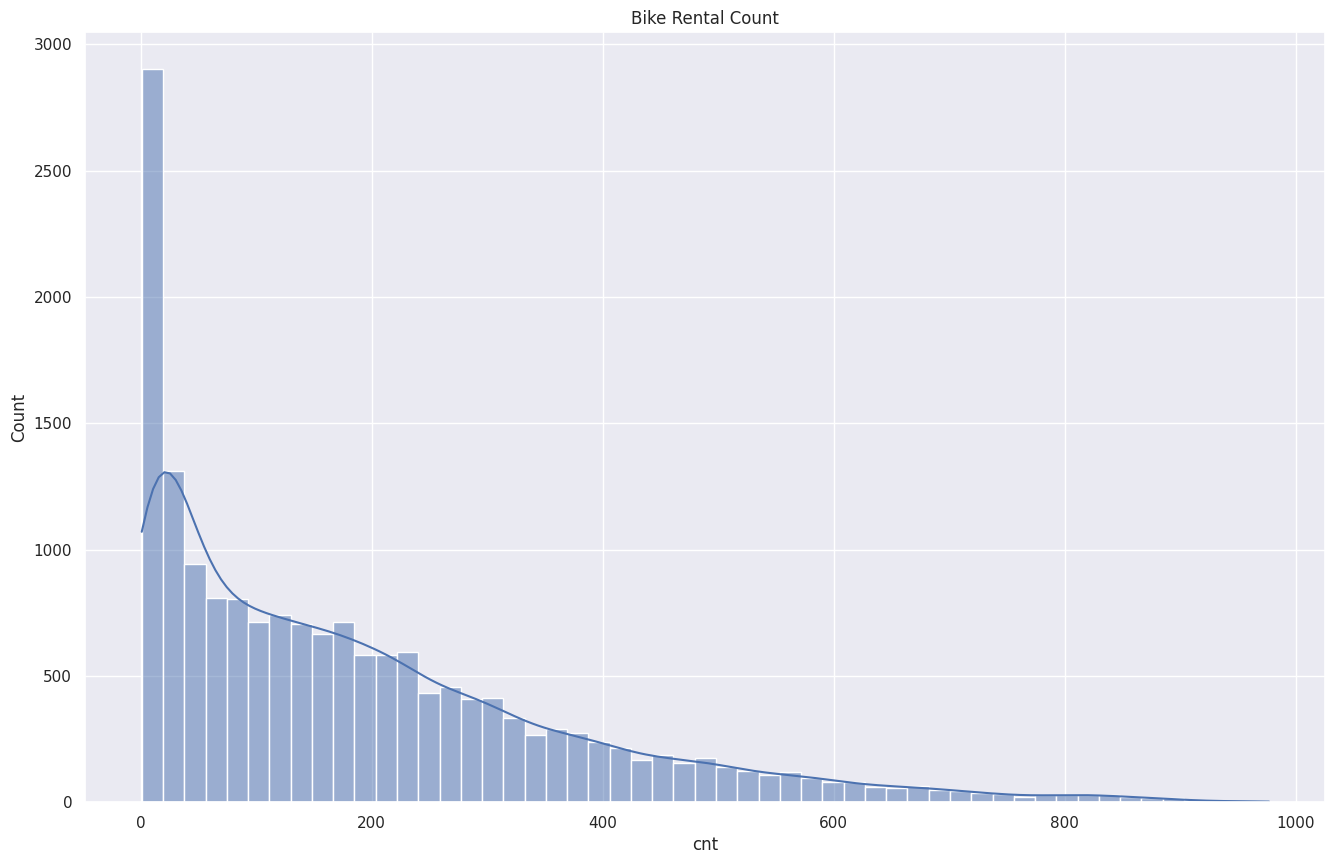

14773    977
14964    976
14748    970
14725    968
15084    967
Name: cnt, dtype: int64


In [55]:
sns.histplot(df['cnt'], kde=True)
plt.title('Bike Rental Count')
plt.show()
print(df['cnt'].nlargest())

* Right-skewed target variable. Range is very large - from near 0 to over 900.

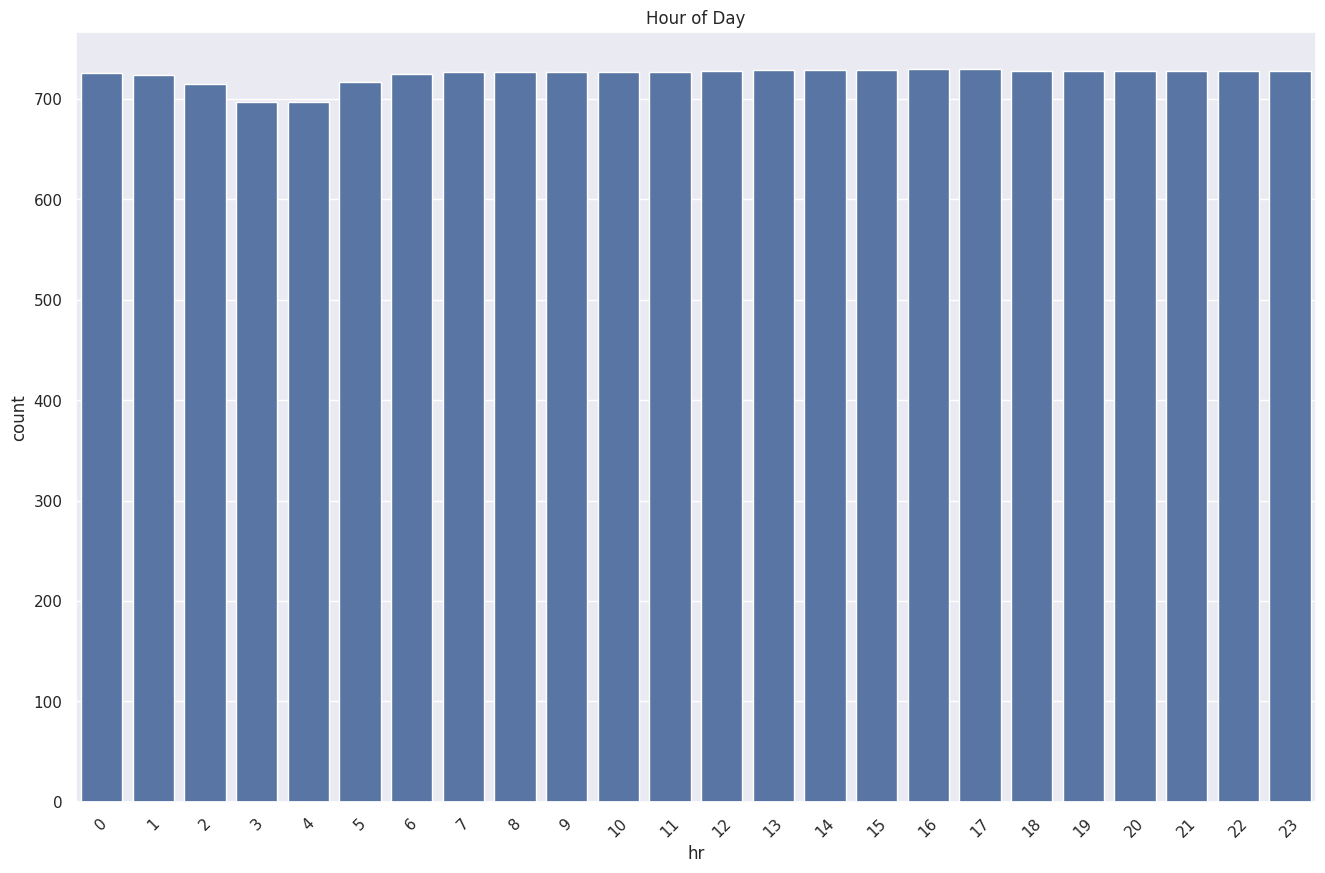

In [56]:
sns.countplot(x='hr', data=df)
plt.title('Hour of Day')
plt.xticks(rotation=45)
plt.show()

* Each hour has approximately 4% of observations.

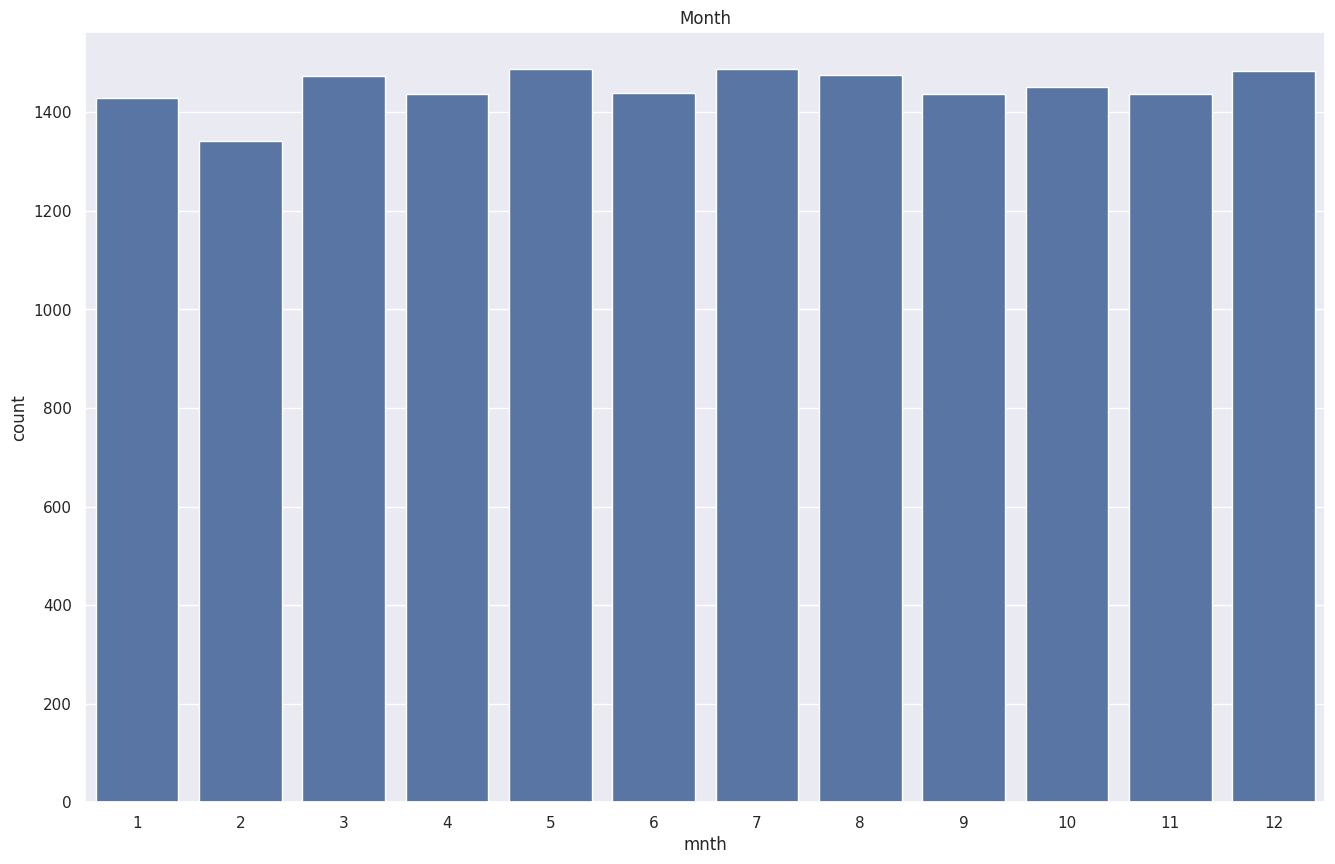

In [57]:
sns.countplot(x='mnth', data=df)
plt.title('Month')
plt.show()

* Each month has approximately 8.5% of observations. February is slightly lower.

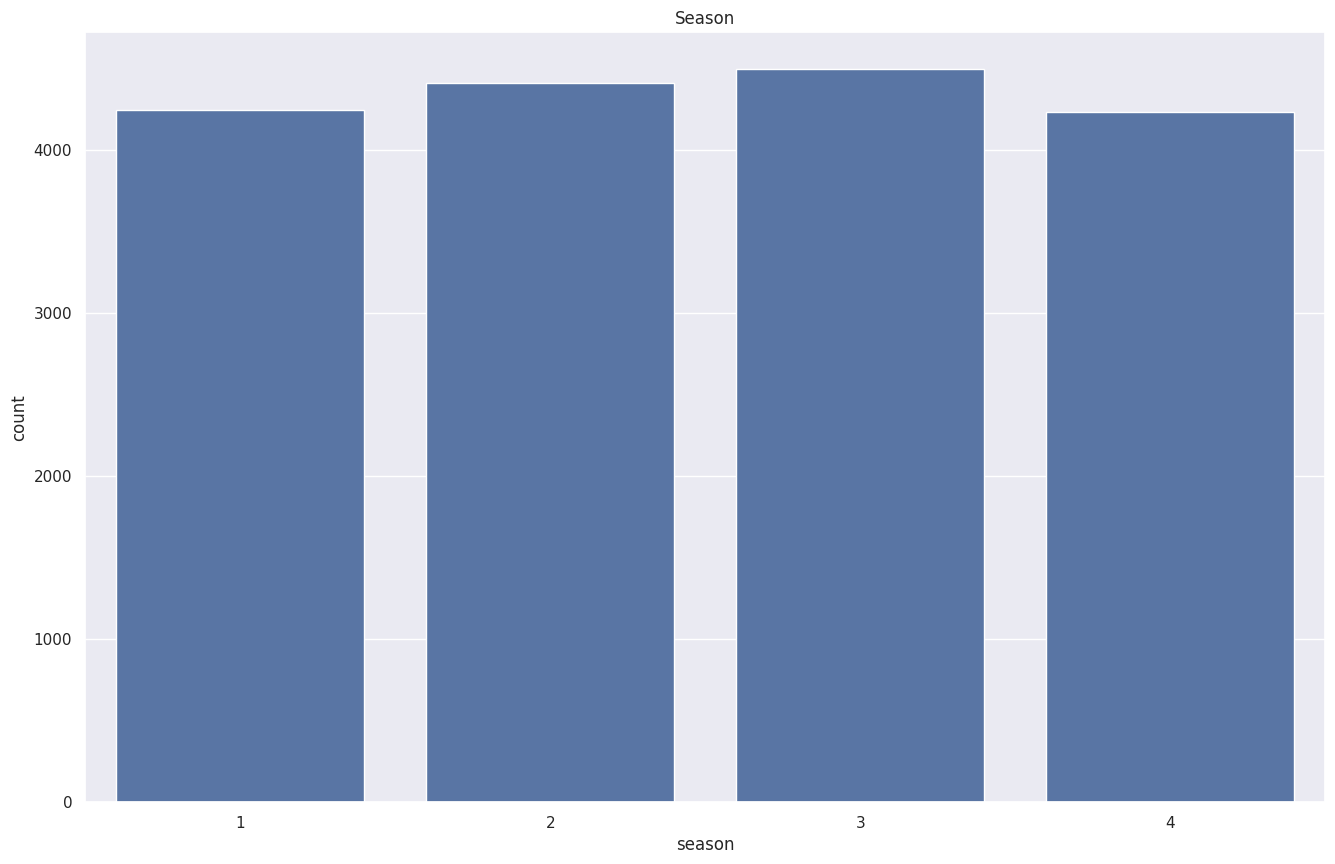

In [58]:
sns.countplot(x='season', data=df)
plt.title('Season')
plt.show()

* Each season has approximately 24% of observations.

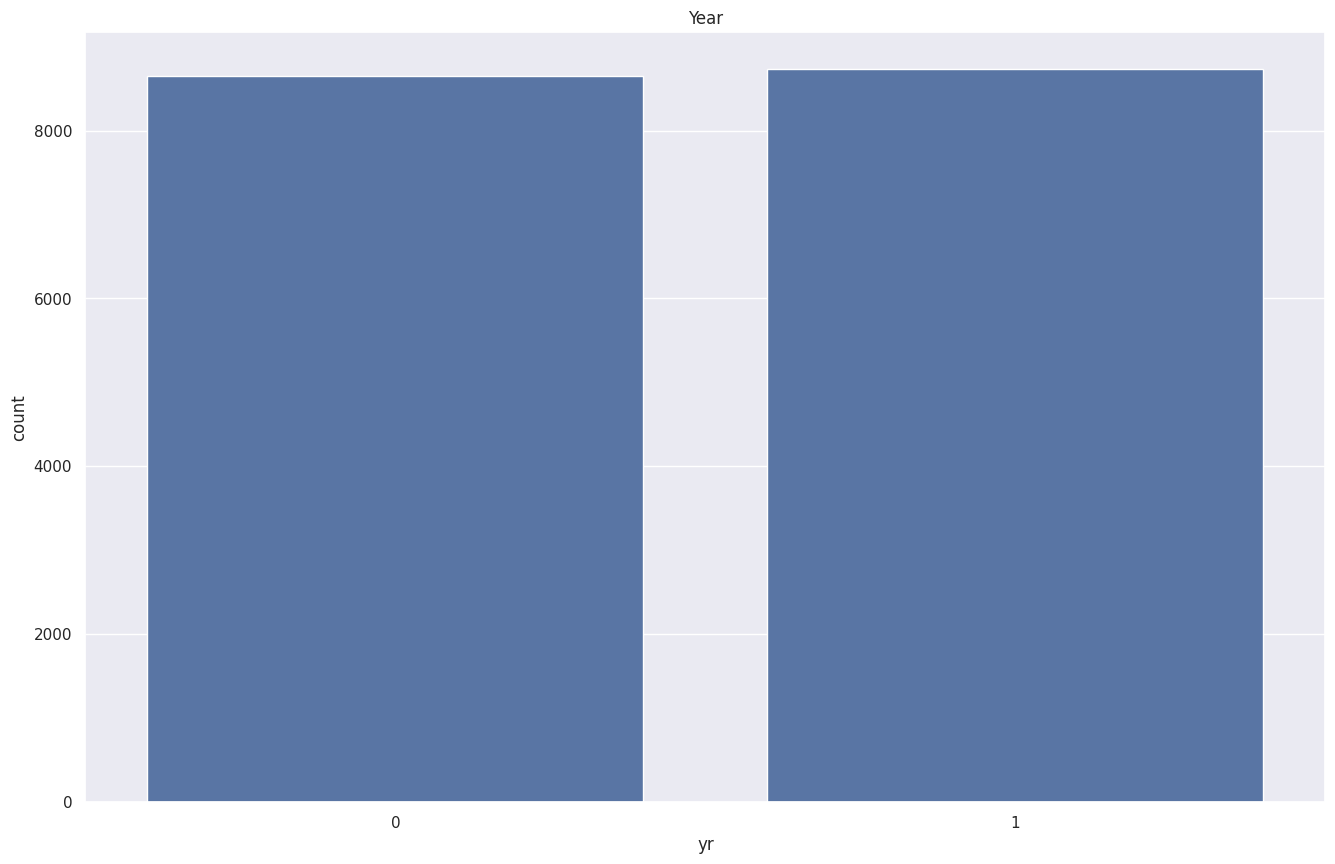

In [59]:
sns.countplot(x='yr', data=df)
plt.title('Year')
plt.show()

* Both years have roughly equal observations.

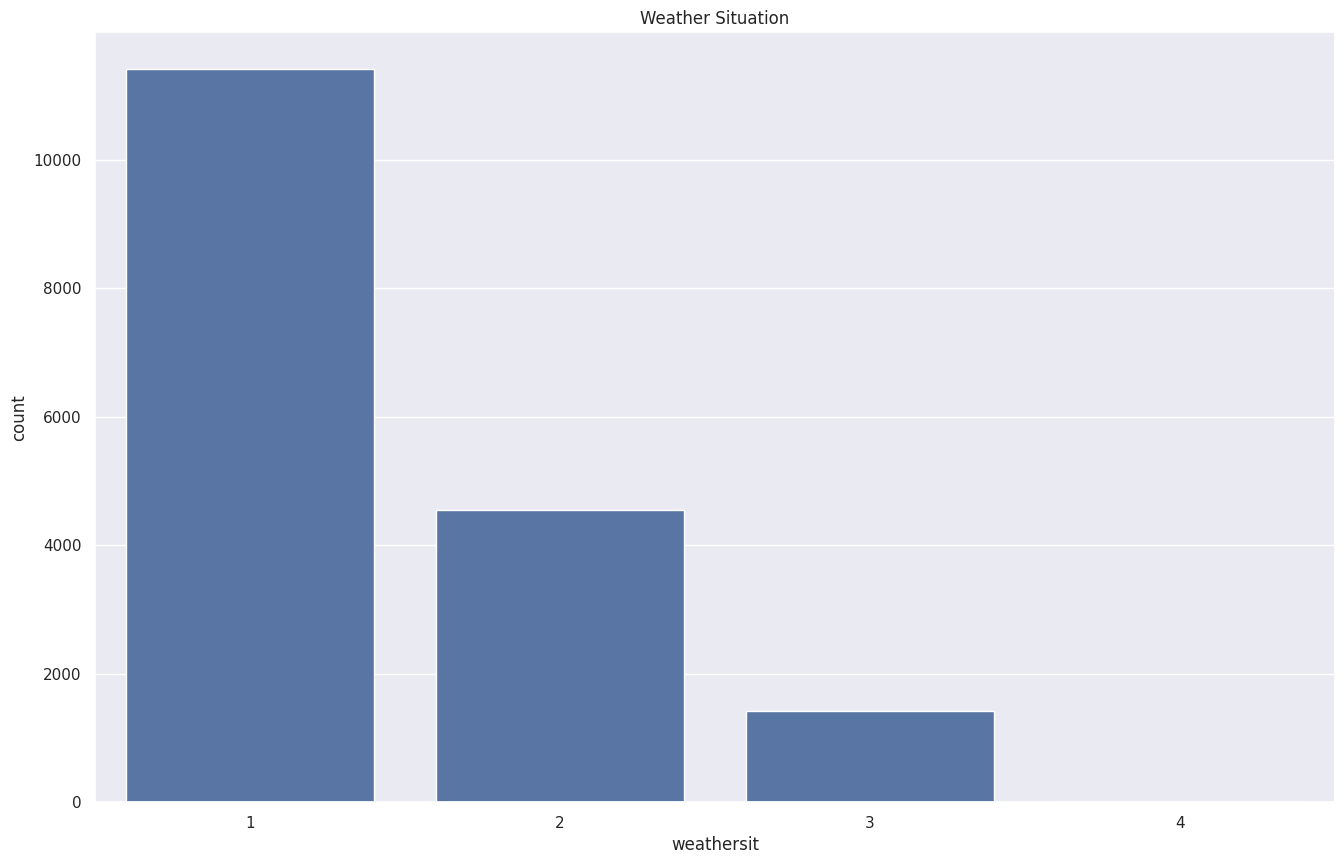

In [60]:
sns.countplot(x='weathersit', data=df)
plt.title('Weather Situation')
plt.show()

* weathersit=1 (clear) has 65.7% observations. weathersit=4 has only 3 observations.

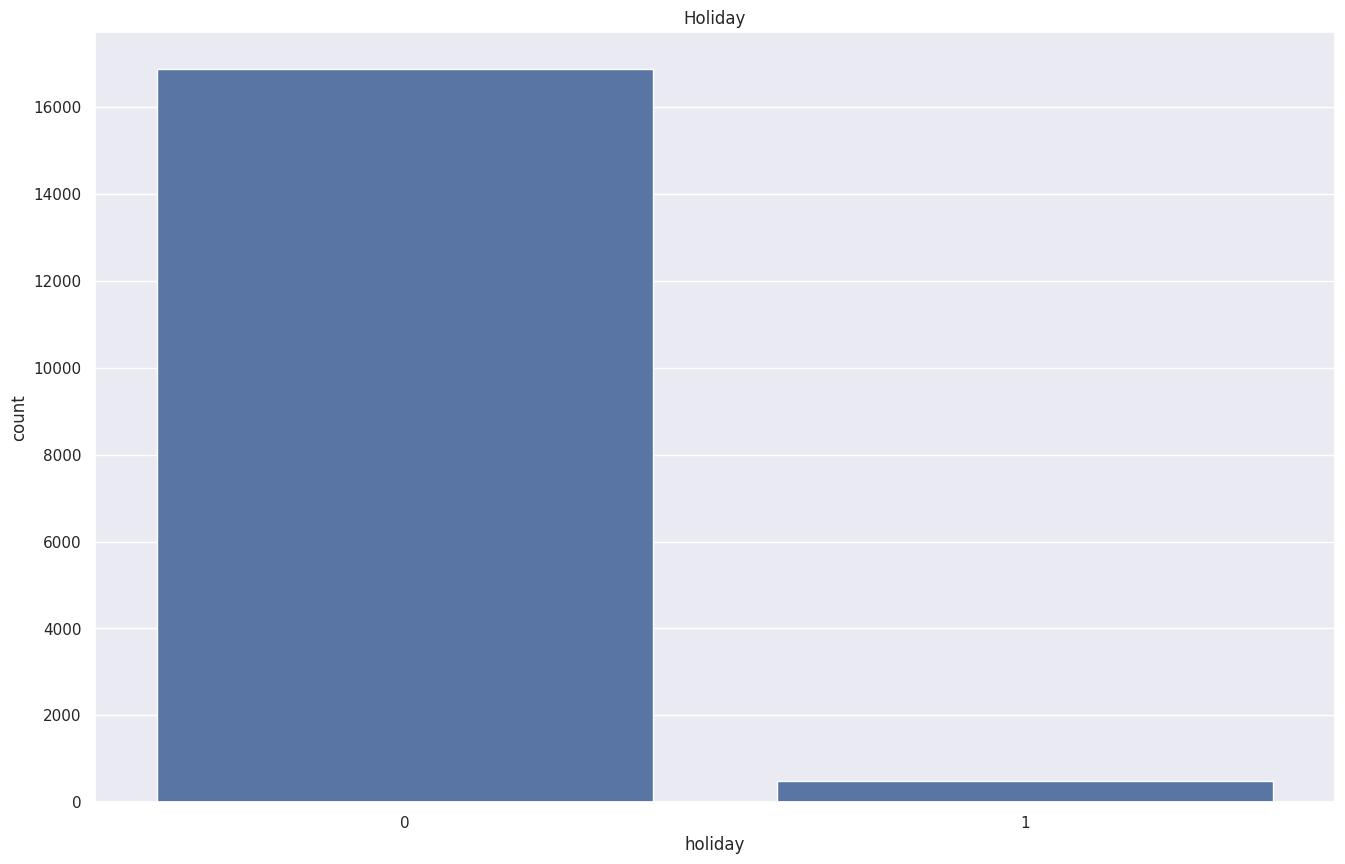

In [61]:
sns.countplot(x='holiday', data=df)
plt.title('Holiday')
plt.show()

* 97% non-holidays, 3% holidays.

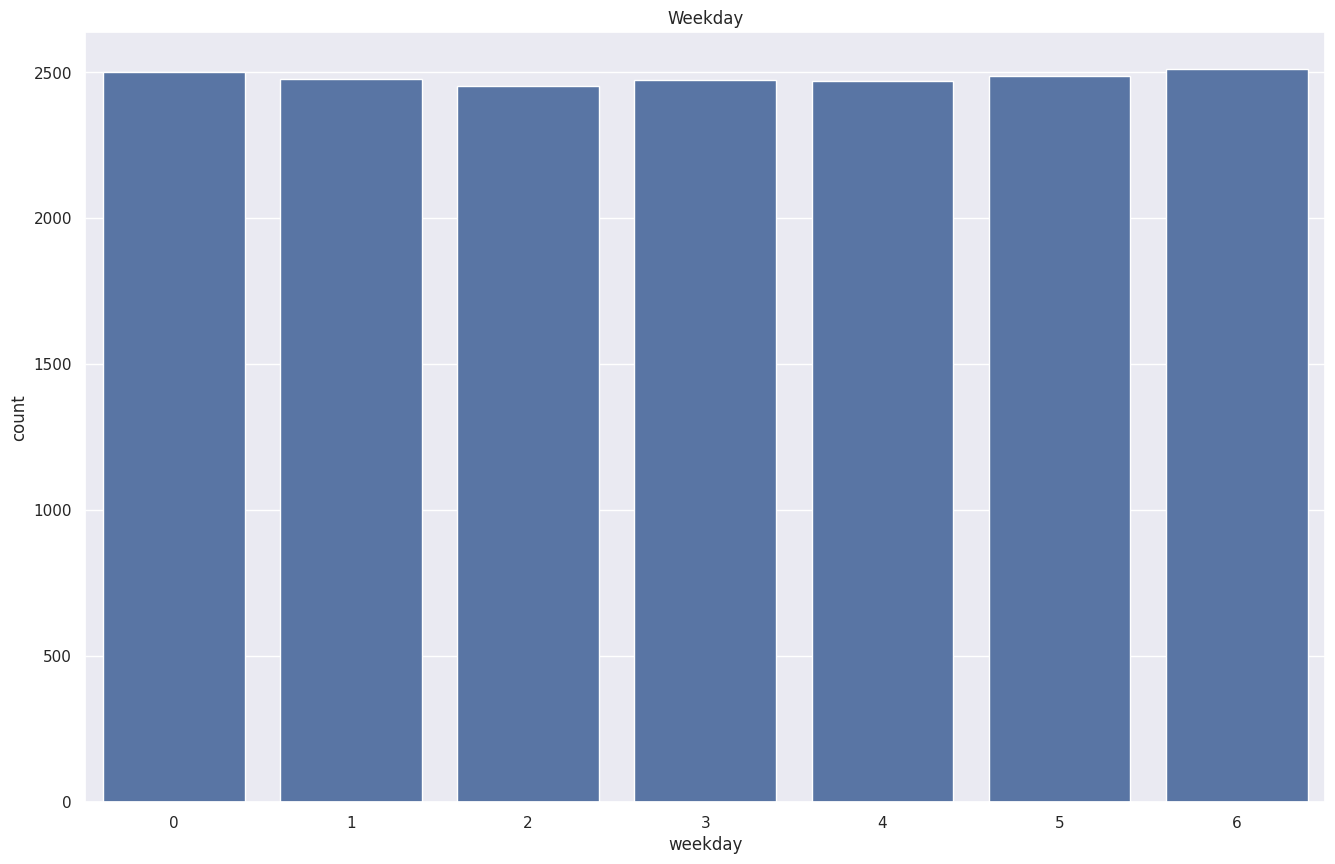

In [62]:
sns.countplot(x='weekday', data=df)
plt.title('Weekday')
plt.show()

* Each weekday has approximately 14% of observations.

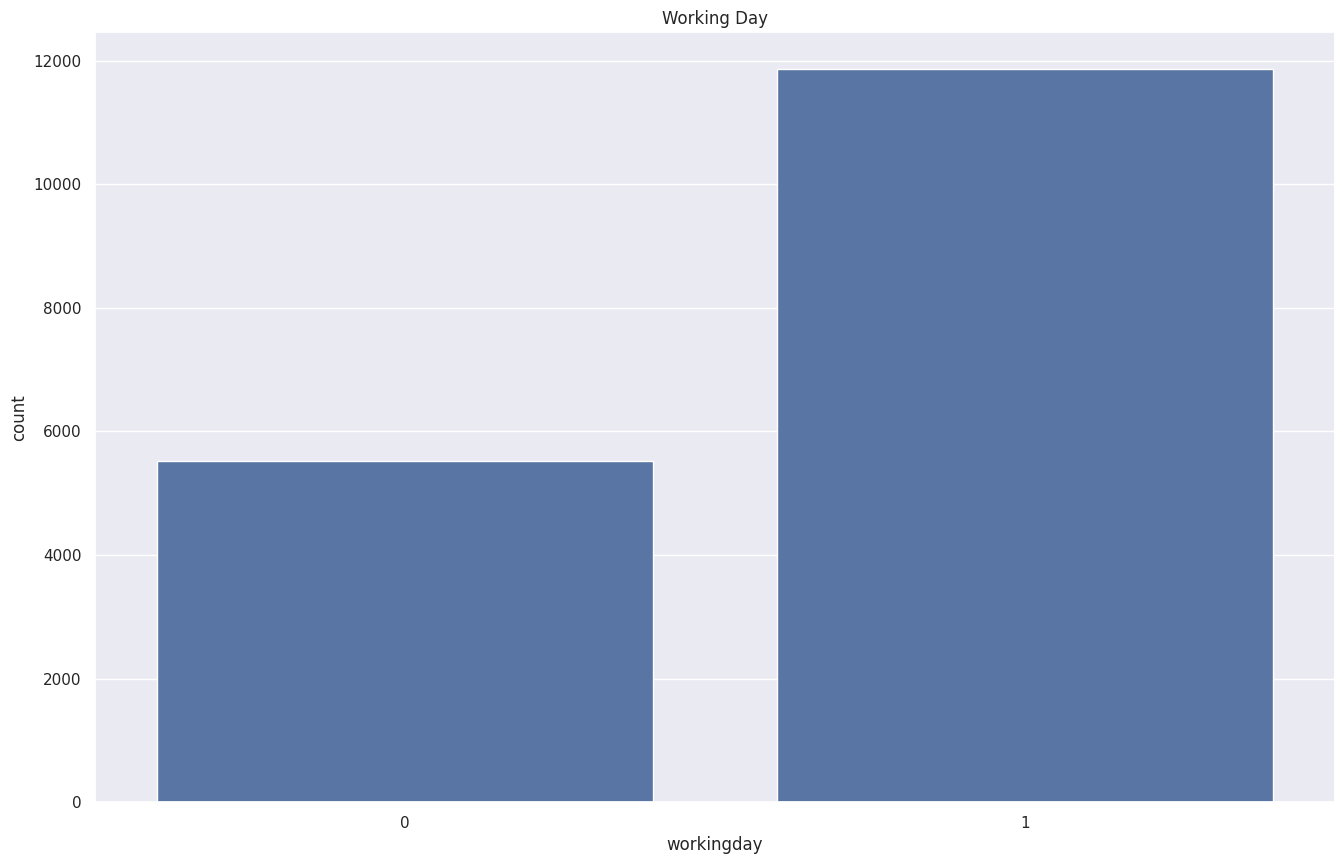

In [63]:
sns.countplot(x='workingday', data=df)
plt.title('Working Day')
plt.show()

* ~68% working days, ~32% non-working days.